In [1]:
from erebus.individual_fit_results import IndividualFitResults
from erebus.joint_fit_results import JointFitResults
import numpy as np
import os
from uncertainties import ufloat
import yaml
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import cm
from matplotlib import colors as colours
from scipy.stats import norm
from erebus.utility.utils import bin_data
from erebus.utility.utils import get_eclipse_duration
from erebus.photometry_data import PhotometryData
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from astropy.time import Time
from erebus.systematics.frame_normalized_pca import perform_fn_pca_on_aperture
from scipy.optimize import curve_fit
from uncertainties import ufloat

plt.rcParams.update({
    'axes.formatter.use_mathtext': True,    
	'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'lines.linewidth': 1.0,
    'figure.dpi': 300,
})

single_column = (3.5, 2.625)
double_column = (7, 5.25)

def get_eclipse_duration_from_res(visit):
	return get_eclipse_duration(
		visit.results['inc'].nominal_value,
		visit.results['a_rstar'].nominal_value,
		visit.results['rp_rstar'].nominal_value,
		visit.results['p'].nominal_value
	) * 24

In [2]:
visit_fits_files = glob("./FNPCA individual fits with fixed tsec/*visit*.h5")
visit_fits = [IndividualFitResults.load(v) for v in visit_fits_files]
visit_fits = sorted(visit_fits, key=lambda x: x.visit_name)

linear_visit_fits_files = glob("./Linear individual fits with fixed tsec/*visit*.h5")
linear_visit_fits = [IndividualFitResults.load(v) for v in linear_visit_fits_files]
linear_visit_fits = sorted(linear_visit_fits, key=lambda x: x.visit_name)

polynomial_visit_fits_files = glob("./Polynomial individual fits with fixed tsec/6px/*visit*.h5")
#polynomial_visit_fits_files = glob("./Polynomial later*/*/*visit*.h5")
polynomial_visit_fits = [IndividualFitResults.load(v) for v in polynomial_visit_fits_files]
polynomial_visit_fits = sorted(polynomial_visit_fits, key=lambda x: x.visit_name)

joint_fit = JointFitResults.load(glob("./FNPCA joint fits with varied aperture size/*5_fnpca*/*joint*.h5")[0])
linear_joint_fit = JointFitResults.load(glob("./Linear joint fits with varied aperture size/*6_linear*/*joint*.h5")[0])
polynomial_joint_fit = JointFitResults.load(glob("./Polynomial joint fits with varied aperture size/*6_polynomial*/*joint*.h5")[0])

2026-06-17 14:17:00,022 - stpipe - WARNING - /home/nicho/.local/lib/python3.11/site-packages/uncertainties/core.py:1024: UserWarning: Using UFloat objects with std_dev==0 may give unexpected results.
  warn("Using UFloat objects with std_dev==0 may give unexpected results.")



In [30]:
def get_eclipse_duration_from_res(visit):
	return get_eclipse_duration(
		visit.results['inc'].nominal_value,
		visit.results['a_rstar'].nominal_value,
		visit.results['rp_rstar'].nominal_value,
		visit.results['p'].nominal_value
	) * 24

def extract_lightcurve(visit, is_joint_fit):
	if is_joint_fit:
		# Joint fit
		bin_size = 200//4
		time = visit.time_per_visit.flatten()
		flux = visit.detrended_flux_per_visit.flatten()
		flux = flux[np.argsort(time)]
		time = np.sort(time)
		time = time[~np.isnan(time)]
		flux = flux[~np.isnan(flux)]
		
		model_time = visit.time_per_visit.flatten()
		model = visit.model_flux_per_visit.flatten()
		model = model[np.argsort(model_time)]
		model_time = np.sort(model_time)
		model = model[~np.isnan(model)]
		model_time = model_time[~np.isnan(model_time)]
	else:
		bin_size = 50
		predicted_t_sec = visit.predicted_t_sec
		time = (visit.time - predicted_t_sec) * 24
		flux = visit.raw_flux / visit.systematic_factor
		model_time = time
		model = visit.flux_model / visit.systematic_factor
	return time, flux, model_time, model, bin_size

def plot_individual(visit, i, visit_index):	
	ax = axs[i, 0]

	time, flux, model_time, model, bin_size = extract_lightcurve(visit, i >= 4)
	
	yerr = visit.results['y_err'].nominal_value
	fp = visit.results['fp'].nominal_value
	fp_err = visit.results['fp'].std_dev

	duration = get_eclipse_duration_from_res(visit)

	# Start time to date
	date_str = None if visit_index < 0 else Time(visit.start_time + 2400000.5, format='jd', scale='tdb').to_datetime().strftime("%B %d, %Y")
	
	binned_time, _ = bin_data(time, bin_size)
	binned_flux, _ = bin_data(flux, bin_size)

	if visit_index == 4:
		binned_time = np.delete(binned_time, [19, 20])
		binned_flux = np.delete(binned_flux, [19, 20])
		cutoff = np.where(model_time > -0.8)[0][0]
		ax.plot(model_time[:cutoff], model[:cutoff], color='red')
		ax.plot(model_time[cutoff:], model[cutoff:], color='red')
	else:
		ax.plot(model_time, model, color='red')

	t_sec = visit.results['t_sec_offset'].nominal_value * 24

	ax.plot(time, flux, marker='.', linestyle='', alpha=0.02, color='black')
	ax.errorbar(binned_time, binned_flux, yerr=yerr / np.sqrt(bin_size), linestyle='', marker='.', color='black')
	ax.axvspan(t_sec - duration / 2.0, t_sec + duration / 2.0, color='red', alpha=0.3)

	display_text = f"Visit {visit_index} - {date_str}" if visit_index >= 0 else "Joint Fit"
	if visit_index == -1:
		display_text += " (Visits 1 - 2)"
	elif visit_index == -2:
		display_text += " (Visits 1 - 3)"
	display_text += f"\nEclipse depth: {fp*1e6:.0f}+/-{fp_err*1e6:.0f}ppm"
	bin_size = 1 if visit_index >= 0 else 4
	display_text += f"\nScatter: {visit.results['y_err'].nominal_value*1e6*np.sqrt(bin_size):0.0f}ppm"
	t_sec_offset = visit.results['t_sec_offset'] * 24 * 60
	display_text += f"\nTiming offset: {t_sec_offset.nominal_value:.0f}+/-{t_sec_offset.std_dev:.0f} min"

	ax.text(0.01, 0.98, display_text, horizontalalignment='left', verticalalignment='top', transform=ax.transAxes)
	ax.minorticks_on()

def plot_allan_deviation(visit, i, visit_index, color='red'):
	time, flux, model_time, model, _ = extract_lightcurve(visit, i >= 4)

	bin_size = 1 if visit_index >= 0 else 4	
	
	def get_res(x, y, bin_size):
		interp_model = np.array([np.interp(xi, model_time, model) for xi in x])
		bin_model = interp_model
		if bin_size > 1:
			x, _ = bin_data(x, bin_size)
			y, _ = bin_data(y, bin_size)
			bin_model, _ = bin_data(interp_model, bin_size)
		res = (y - bin_model) * 1000000 # To ppm
		rms = np.sqrt(np.mean(res**2)) 
		return rms
	
	allan_ax = axs[i, 1]

	n = np.arange(1, 200)
	r = np.array([get_res(time, flux, i)* np.sqrt(bin_size) for i in n]) 
	r_ideal = r[0]/np.sqrt(n)

	allan_ax.plot(n, r, color=color, linestyle='-' if color == 'red' else '--')
	if color == 'red':
		allan_ax.plot(n, r_ideal, linestyle='--', color='black')
	allan_ax.set_xscale('log')
	allan_ax.set_yscale('log')
	allan_ax.set_xlabel("Bin size")
	allan_ax.set_xticks([1, 10, 100])
	allan_ax.set_xticklabels(["1", "10", "100"])
	allan_ax.set_yticks([10, 100, 1000])
	allan_ax.set_yticklabels(["10", "100", "1000"])
	allan_ax.set_ylim([20, 1000])
	#allan_ax.set_ylabel("RMS of residuals")
	#allan_ax.minorticks_off()

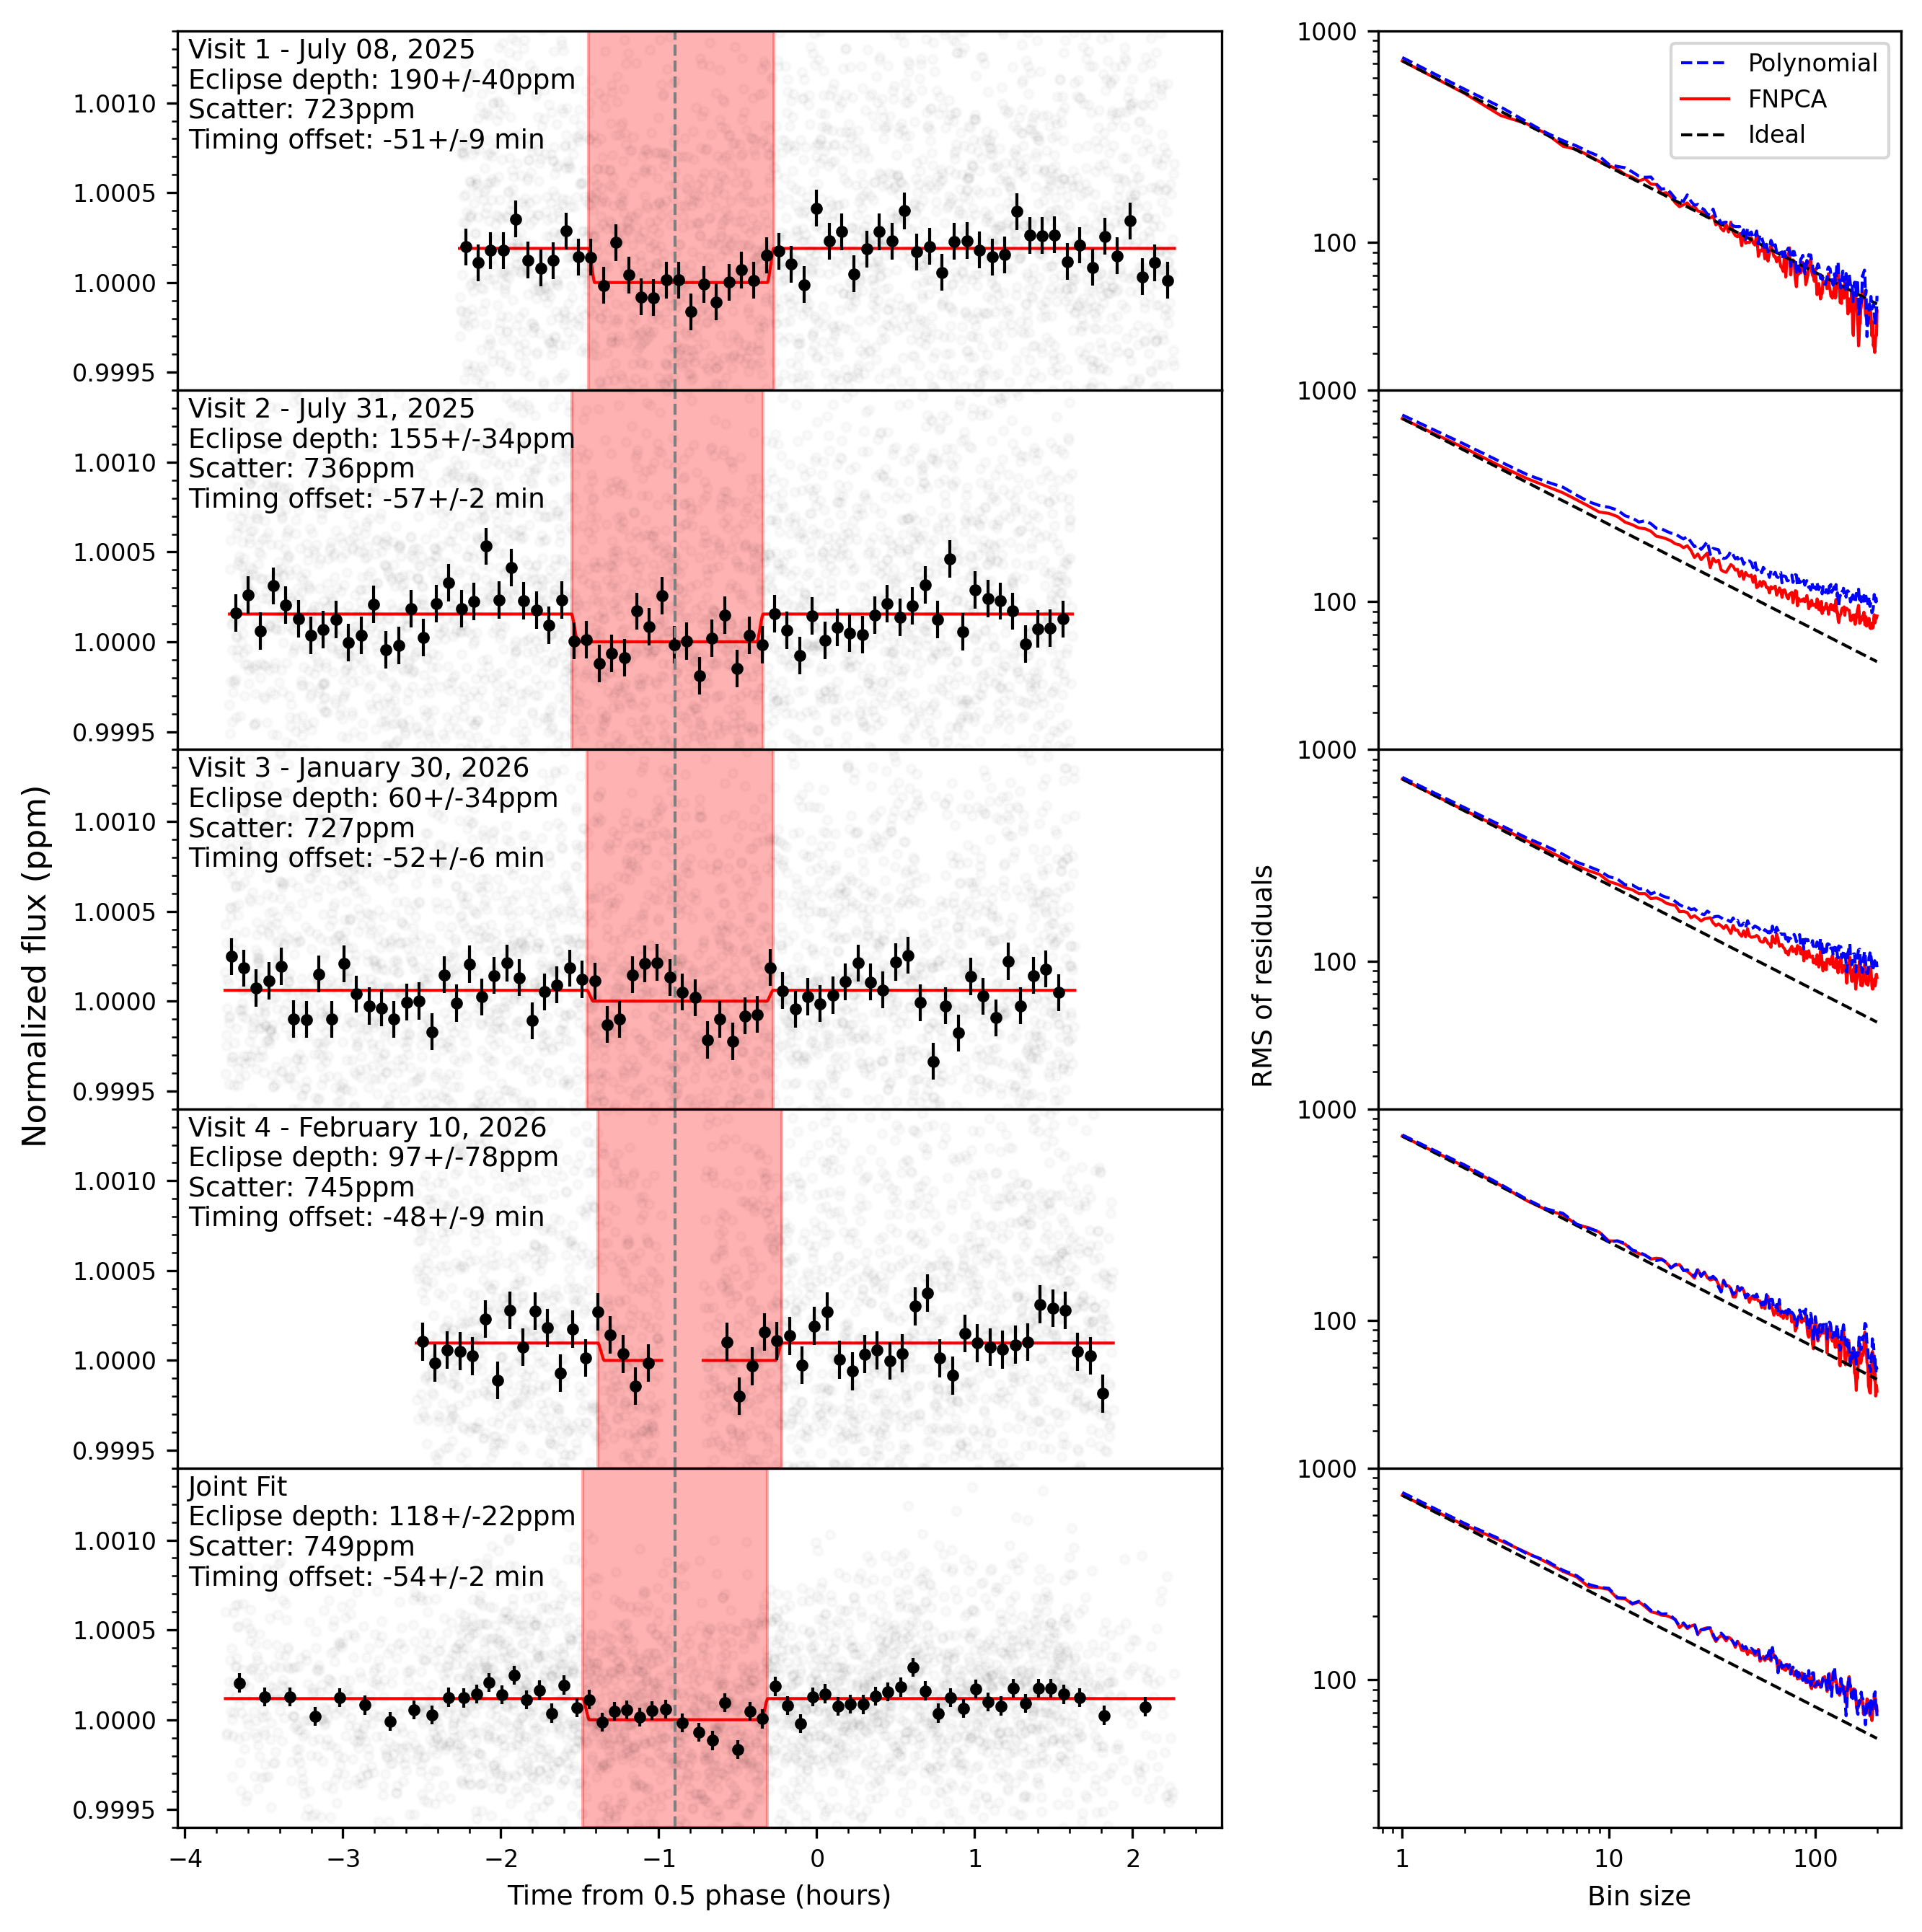

In [31]:
fig, axs = plt.subplots(5, 2, figsize=(9, 9), sharey='col', sharex='col', gridspec_kw={'width_ratios': [2, 1]})

plot_individual(visit_fits[0], 0, 1)
plot_individual(visit_fits[1], 1, 2)
plot_individual(visit_fits[2], 2, 3)
plot_individual(visit_fits[3], 3, 4)
plot_individual(joint_fit, 4, -4)

plot_allan_deviation(visit_fits[0], 0, 1)
plot_allan_deviation(visit_fits[1], 1, 2)
plot_allan_deviation(visit_fits[2], 2, 3)
plot_allan_deviation(visit_fits[3], 3, 4)
plot_allan_deviation(joint_fit, 4, -4)

plot_allan_deviation(polynomial_visit_fits[0], 0, 1, 'blue')
plot_allan_deviation(polynomial_visit_fits[1], 1, 2, 'blue')
plot_allan_deviation(polynomial_visit_fits[2], 2, 3, 'blue')
plot_allan_deviation(polynomial_visit_fits[3], 3, 4, 'blue')
plot_allan_deviation(polynomial_joint_fit, 4, -4, 'blue')

for ax in axs[:,0]:
	ax.axvline(joint_fit.results['t_sec_offset'].nominal_value * 24, linestyle='--', color='grey')

for ax in axs[:,0]:
	ax.set_ylim([0.9994, 1.0014])
	ax.set_yticks([0.9995, 1, 1.0005, 1.001])
	ax.set_yticklabels([0.9995, '1.0000', 1.0005, '1.0010'])
	#ax.set_xlim([-3, 2])

fig.supylabel("Normalized flux (ppm)")
axs[-1, 0].set_xlabel("Time from 0.5 phase (hours)")

rms_axs = axs[:, 1]

y_top = rms_axs[0].get_position().y1
y_bot = rms_axs[-1].get_position().y0
y_center = (y_top + y_bot) / 2
x_left = rms_axs[0].get_position().x0

axs[0, 1].plot([], [], color='blue', linestyle='--', label='Polynomial')
axs[0, 1].plot([], [], color='red', label='FNPCA')
axs[0, 1].plot([], [], color='black', linestyle='--', label='Ideal')
axs[0, 1].legend()


fig.text(x_left, y_center, 'RMS of residuals', va='center', ha='right', rotation='vertical')

plt.tight_layout()
plt.subplots_adjust(hspace=0, wspace=0.2)
plt.savefig("figures/combined_results.png", bbox_inches='tight')
plt.savefig("figures/combined_results.pdf", bbox_inches='tight')
plt.show()

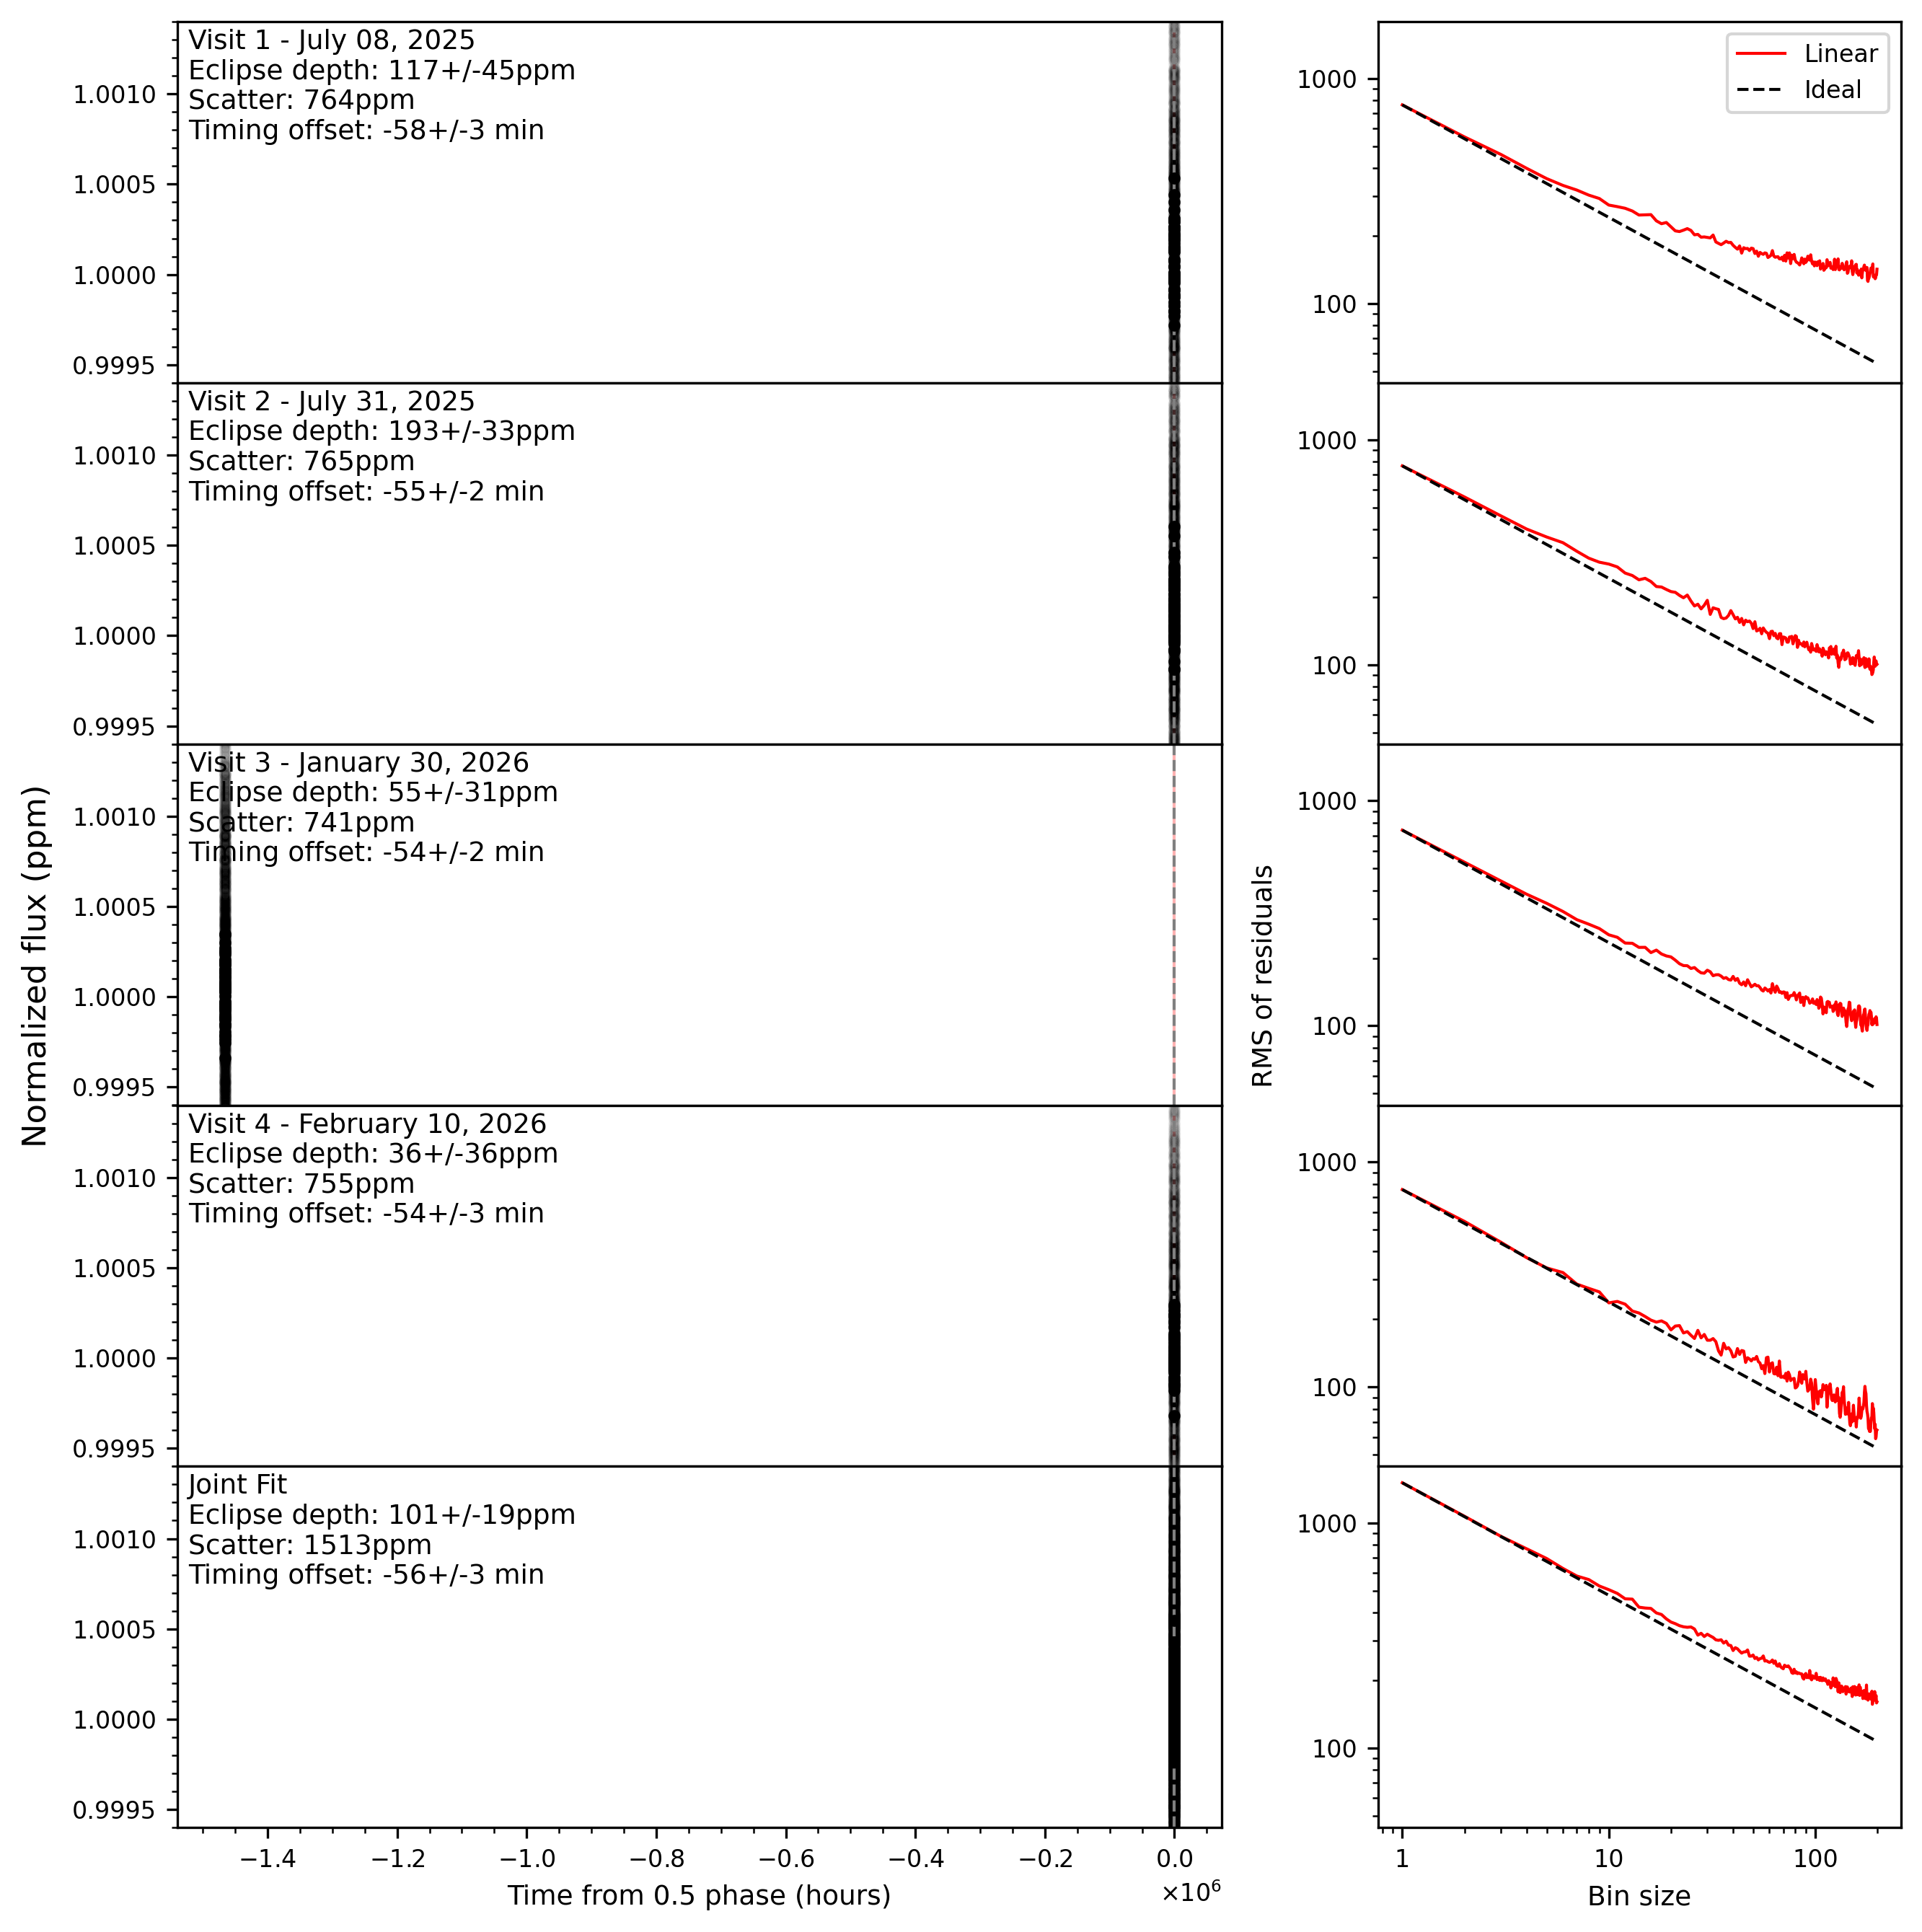

In [25]:
fig, axs = plt.subplots(5, 2, figsize=(9, 9), sharey='col', sharex='col', gridspec_kw={'width_ratios': [2, 1]})

plot_individual(linear_visit_fits[0], 0, 1)
plot_individual(linear_visit_fits[1], 1, 2)
plot_individual(linear_visit_fits[2], 2, 3)
plot_individual(linear_visit_fits[3], 3, 4)
plot_individual(linear_joint_fit, 4, -4)

plot_allan_deviation(linear_visit_fits[0], 0, 1)
plot_allan_deviation(linear_visit_fits[1], 1, 2)
plot_allan_deviation(linear_visit_fits[2], 2, 3)
plot_allan_deviation(linear_visit_fits[3], 3, 4)
plot_allan_deviation(linear_joint_fit, 4, -4)

for ax in axs[:,0]:
	ax.axvline(linear_joint_fit.results['t_sec_offset'].nominal_value * 24, linestyle='--', color='grey')

for ax in axs[:,0]:
	ax.set_ylim([0.9994, 1.0014])
	ax.set_yticks([0.9995, 1, 1.0005, 1.001])
	ax.set_yticklabels([0.9995, '1.0000', 1.0005, '1.0010'])
	#ax.set_xlim([-3, 2])

fig.supylabel("Normalized flux (ppm)")
axs[-1, 0].set_xlabel("Time from 0.5 phase (hours)")

rms_axs = axs[:, 1]

y_top = rms_axs[0].get_position().y1
y_bot = rms_axs[-1].get_position().y0
y_center = (y_top + y_bot) / 2
x_left = rms_axs[0].get_position().x0

#axs[0, 1].plot([], [], color='blue', label='Linear')
axs[0, 1].plot([], [], color='red', label='Linear')
axs[0, 1].plot([], [], color='black', linestyle='--', label='Ideal')
axs[0, 1].legend()


fig.text(x_left, y_center, 'RMS of residuals', va='center', ha='right', rotation='vertical')

plt.tight_layout()
plt.subplots_adjust(hspace=0, wspace=0.2)
#plt.savefig("figures/combined_results.png", bbox_inches='tight')
#plt.savefig("figures/combined_results.pdf", bbox_inches='tight')
plt.show()

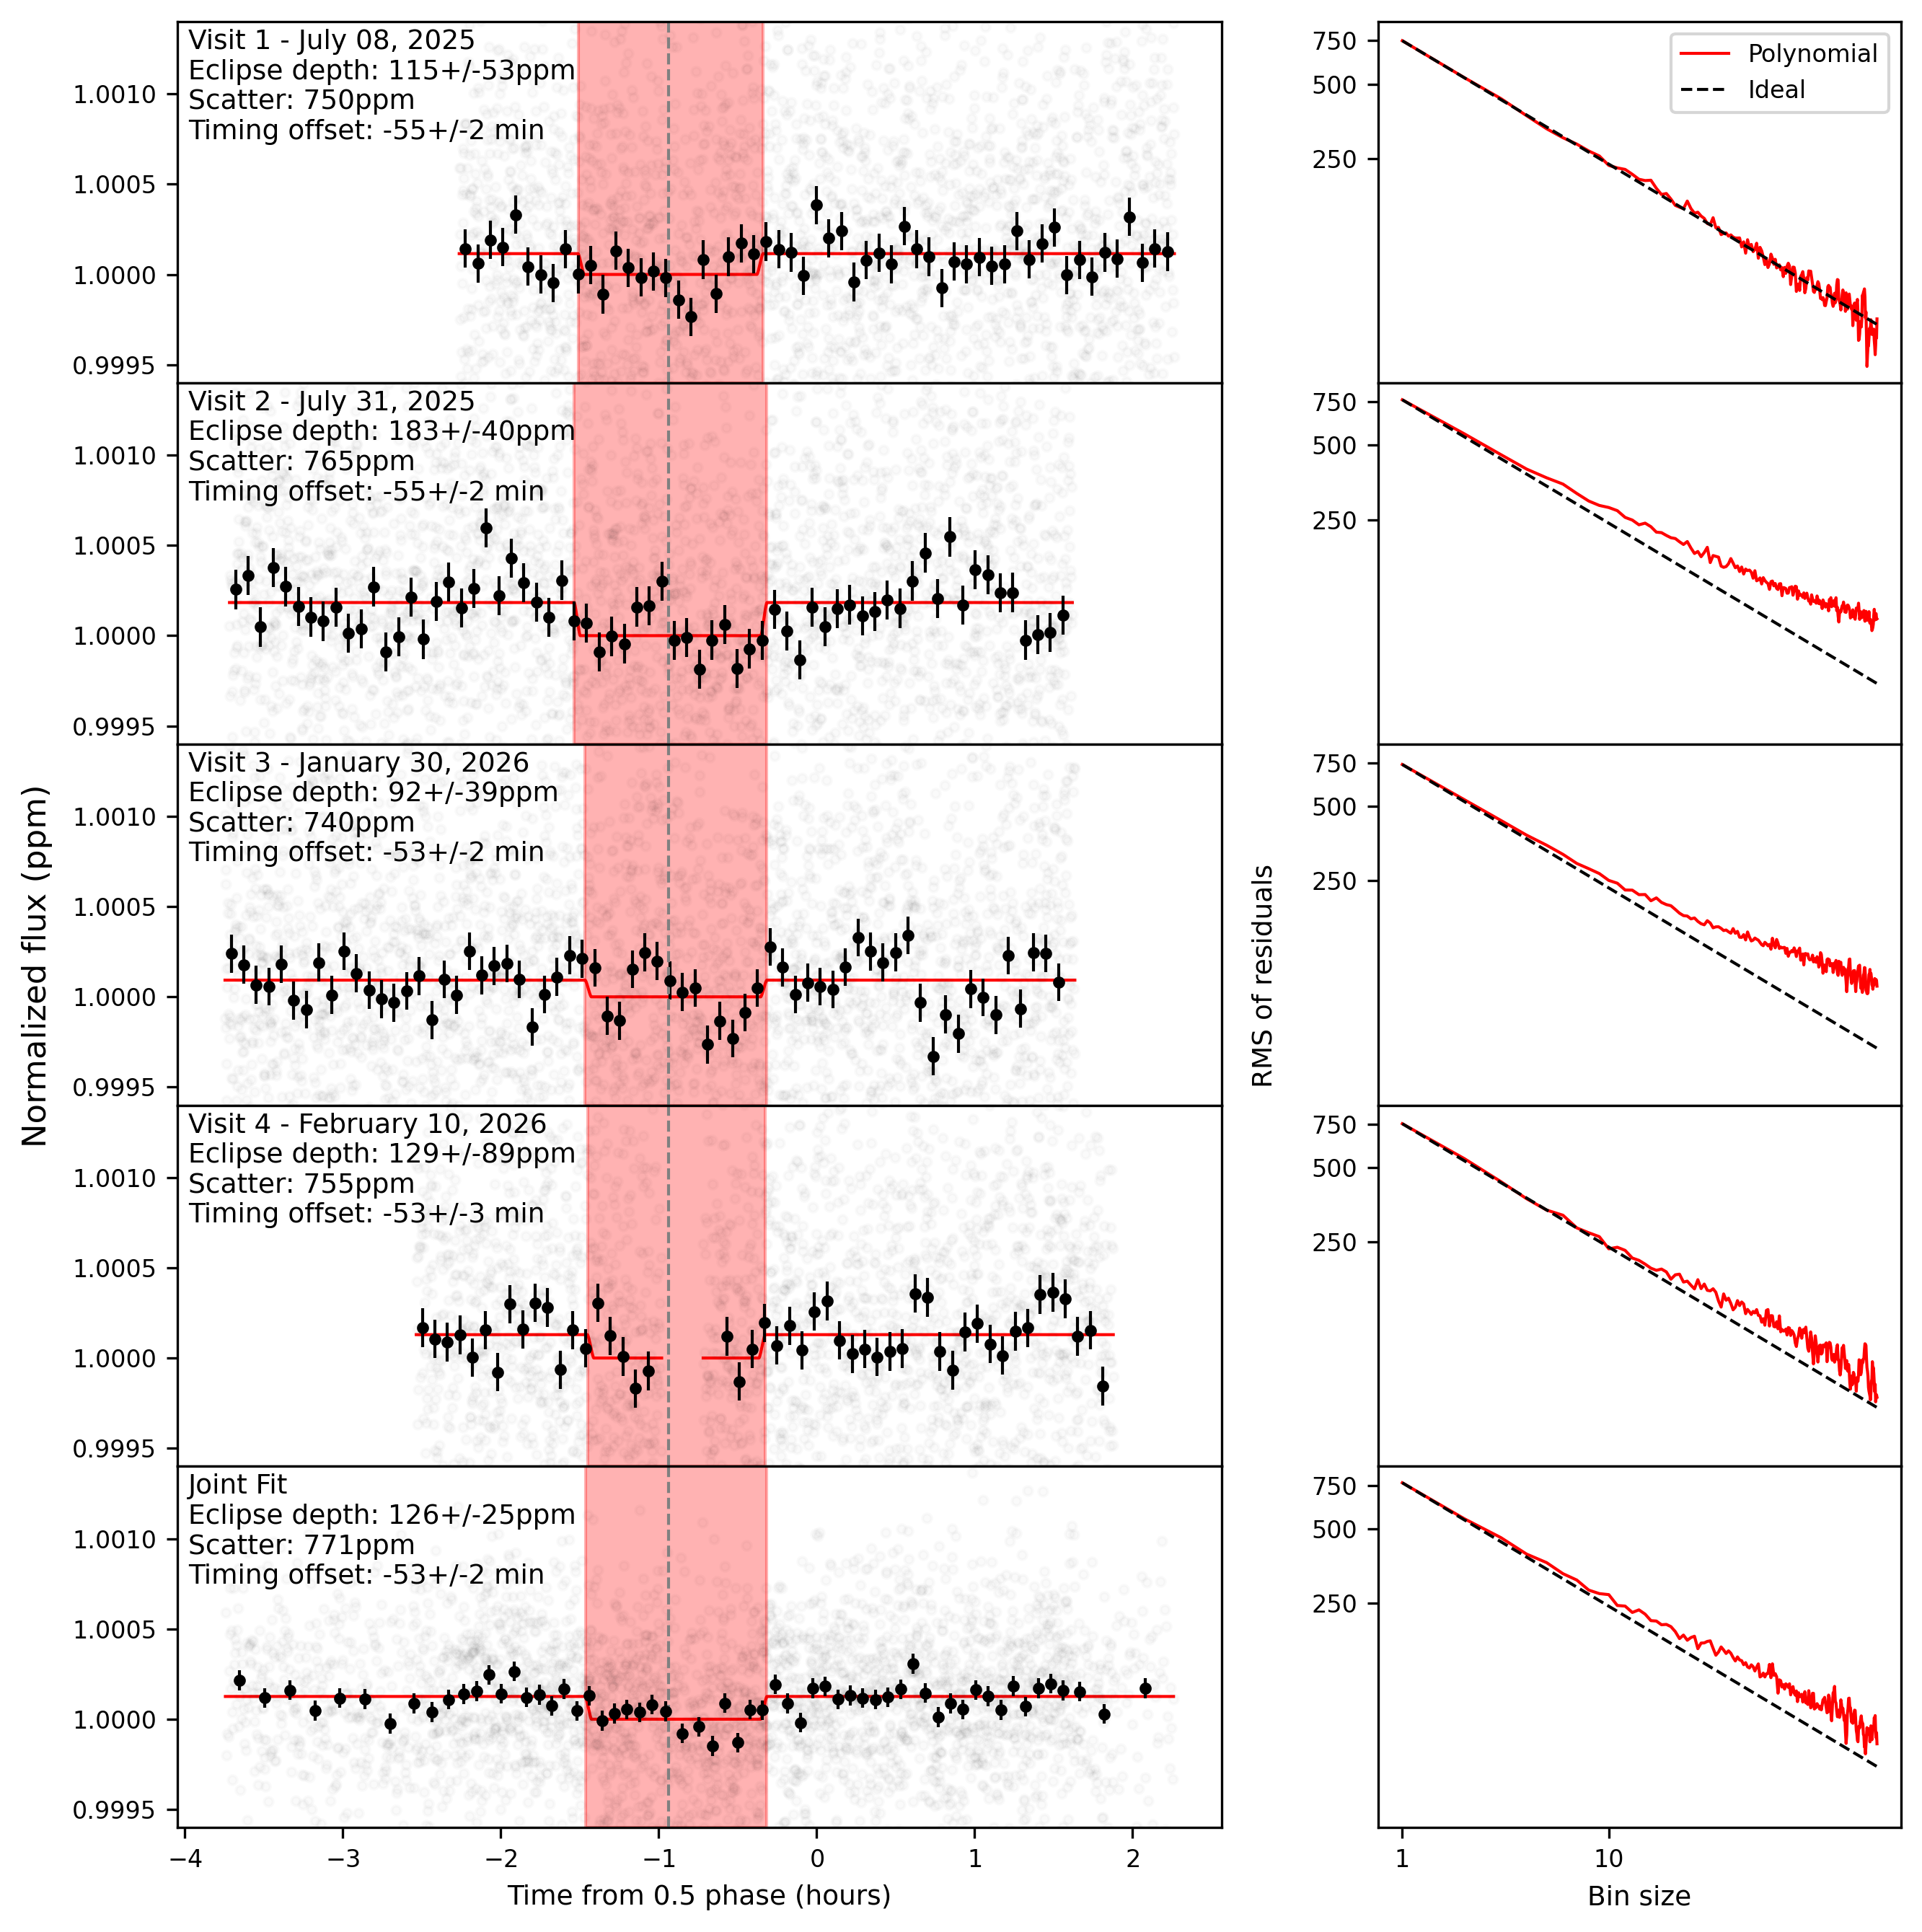

In [6]:
fig, axs = plt.subplots(5, 2, figsize=(9, 9), sharey='col', sharex='col', gridspec_kw={'width_ratios': [2, 1]})

plot_individual(polynomial_visit_fits[0], 0, 1)
plot_individual(polynomial_visit_fits[1], 1, 2)
plot_individual(polynomial_visit_fits[2], 2, 3)
plot_individual(polynomial_visit_fits[3], 3, 4)
plot_individual(polynomial_joint_fit, 4, -4)

plot_allan_deviation(polynomial_visit_fits[0], 0, 1)
plot_allan_deviation(polynomial_visit_fits[1], 1, 2)
plot_allan_deviation(polynomial_visit_fits[2], 2, 3)
plot_allan_deviation(polynomial_visit_fits[3], 3, 4)
plot_allan_deviation(polynomial_joint_fit, 4, -4)

for ax in axs[:,0]:
	ax.axvline(linear_joint_fit.results['t_sec_offset'].nominal_value * 24, linestyle='--', color='grey')

for ax in axs[:,0]:
	ax.set_ylim([0.9994, 1.0014])
	ax.set_yticks([0.9995, 1, 1.0005, 1.001])
	ax.set_yticklabels([0.9995, '1.0000', 1.0005, '1.0010'])
	#ax.set_xlim([-3, 2])

fig.supylabel("Normalized flux (ppm)")
axs[-1, 0].set_xlabel("Time from 0.5 phase (hours)")

rms_axs = axs[:, 1]

y_top = rms_axs[0].get_position().y1
y_bot = rms_axs[-1].get_position().y0
y_center = (y_top + y_bot) / 2
x_left = rms_axs[0].get_position().x0

#axs[0, 1].plot([], [], color='blue', label='Linear')
axs[0, 1].plot([], [], color='red', label='Polynomial')
axs[0, 1].plot([], [], color='black', linestyle='--', label='Ideal')
axs[0, 1].legend()


fig.text(x_left, y_center, 'RMS of residuals', va='center', ha='right', rotation='vertical')

plt.tight_layout()
plt.subplots_adjust(hspace=0, wspace=0.2)
#plt.savefig("figures/combined_results.png", bbox_inches='tight')
#plt.savefig("figures/combined_results.pdf", bbox_inches='tight')
plt.show()

125+/-25
-52.1+/-3.5


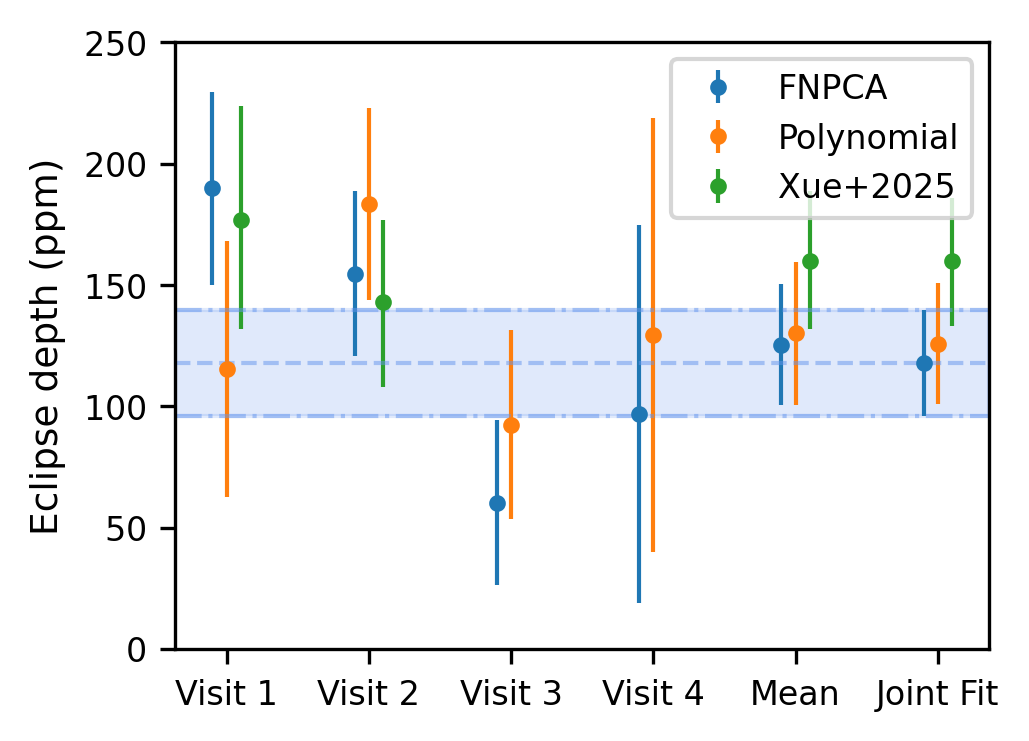

In [7]:
d = np.mean([f.results['fp'] for f in visit_fits])
polynomial_d = np.mean([f.results['fp'] for f in polynomial_visit_fits])
t_sec = np.mean([f.results['t_sec_offset'] for f in visit_fits])

print(d*1e6)
print(t_sec*24*60)

# FNPCA
x = np.arange(6)
y = np.concatenate(([f.results['fp'] for f in visit_fits], [d], [joint_fit.results['fp']]))
y_err = np.array([yi.std_dev for yi in y]) * 1e6
y = np.array([yi.nominal_value for yi in y]) * 1e6

# Linear
x = np.arange(6)
polynomial_y = np.concatenate(([f.results['fp'] for f in polynomial_visit_fits], [polynomial_d], [polynomial_joint_fit.results['fp']]))
polynomial_y_err = np.array([yi.std_dev for yi in polynomial_y]) * 1e6
polynomial_y = np.array([yi.nominal_value for yi in polynomial_y]) * 1e6

#Xue et al 2025
xue_x = np.array([0, 1, 4, 5])
xue_y = [177, 143, (177+143)/2.0, 160]
xue_y_err_upper = [47, 34, (47+34)/(2 * np.sqrt(2)), 26]
xue_y_err_lower = [45, 35, (45 + 35)/(2 * np.sqrt(2)), 27]

plt.figure(figsize=single_column)
plt.errorbar(x - 0.1, y, y_err, marker='.', linestyle='', label='FNPCA')
plt.errorbar(x, polynomial_y, polynomial_y_err, marker='.', linestyle='', label='Polynomial')
plt.errorbar(xue_x + 0.1, xue_y, [xue_y_err_lower, xue_y_err_upper], marker='.', linestyle='', label='Xue+2025')
ax = plt.gca()
ax.set_xticks(x)
ax.set_xticklabels(["Visit 1", "Visit 2", "Visit 3", "Visit 4", "Mean", "Joint Fit"])

plt.axhspan(y[-1] - y_err[-1], y[-1] + y_err[-1], alpha=0.2, color='cornflowerblue')
plt.axhline(y[-1], linestyle='--', color='cornflowerblue', alpha=0.5)
plt.axhline(y[-1] - y_err[-1], linestyle='-.', color='cornflowerblue', alpha=0.5)
plt.axhline(y[-1] + y_err[-1], linestyle='-.', color='cornflowerblue', alpha=0.5)
plt.ylim([0, 250])

plt.ylabel("Eclipse depth (ppm)")
plt.legend()
plt.savefig("figures/eclipse_depths.png", bbox_inches='tight')
plt.savefig("figures/eclipse_depths.pdf", bbox_inches='tight')

In [8]:
print([f.results['fp']*1e6 for f in linear_visit_fits])
print(polynomial_d*1e6)

[117.26201725308304+/-44.80969446691201, 192.80460166198455+/-32.54682564210779, 54.85840424157174+/-30.663354330294997, 36.15098411574909+/-36.419491827800066]
130+/-29


In [9]:
linear_visit_fits[0].__dict__.keys()


dict_keys(['BIC', 'config', 'config_hash', 'final_log_likelihood', 'order', 'planet', 'planet_name', 'predicted_t_sec', 'results', 'start_time', 'visit_name', 'eigenvalues', 'eigenvectors', 'flux_model', 'frames', 'pca_variance_ratios', 'raw_flux', 'systematic_factor', 'time'])

[-0.14597774  0.04888351 -0.00625841  1.00024225]


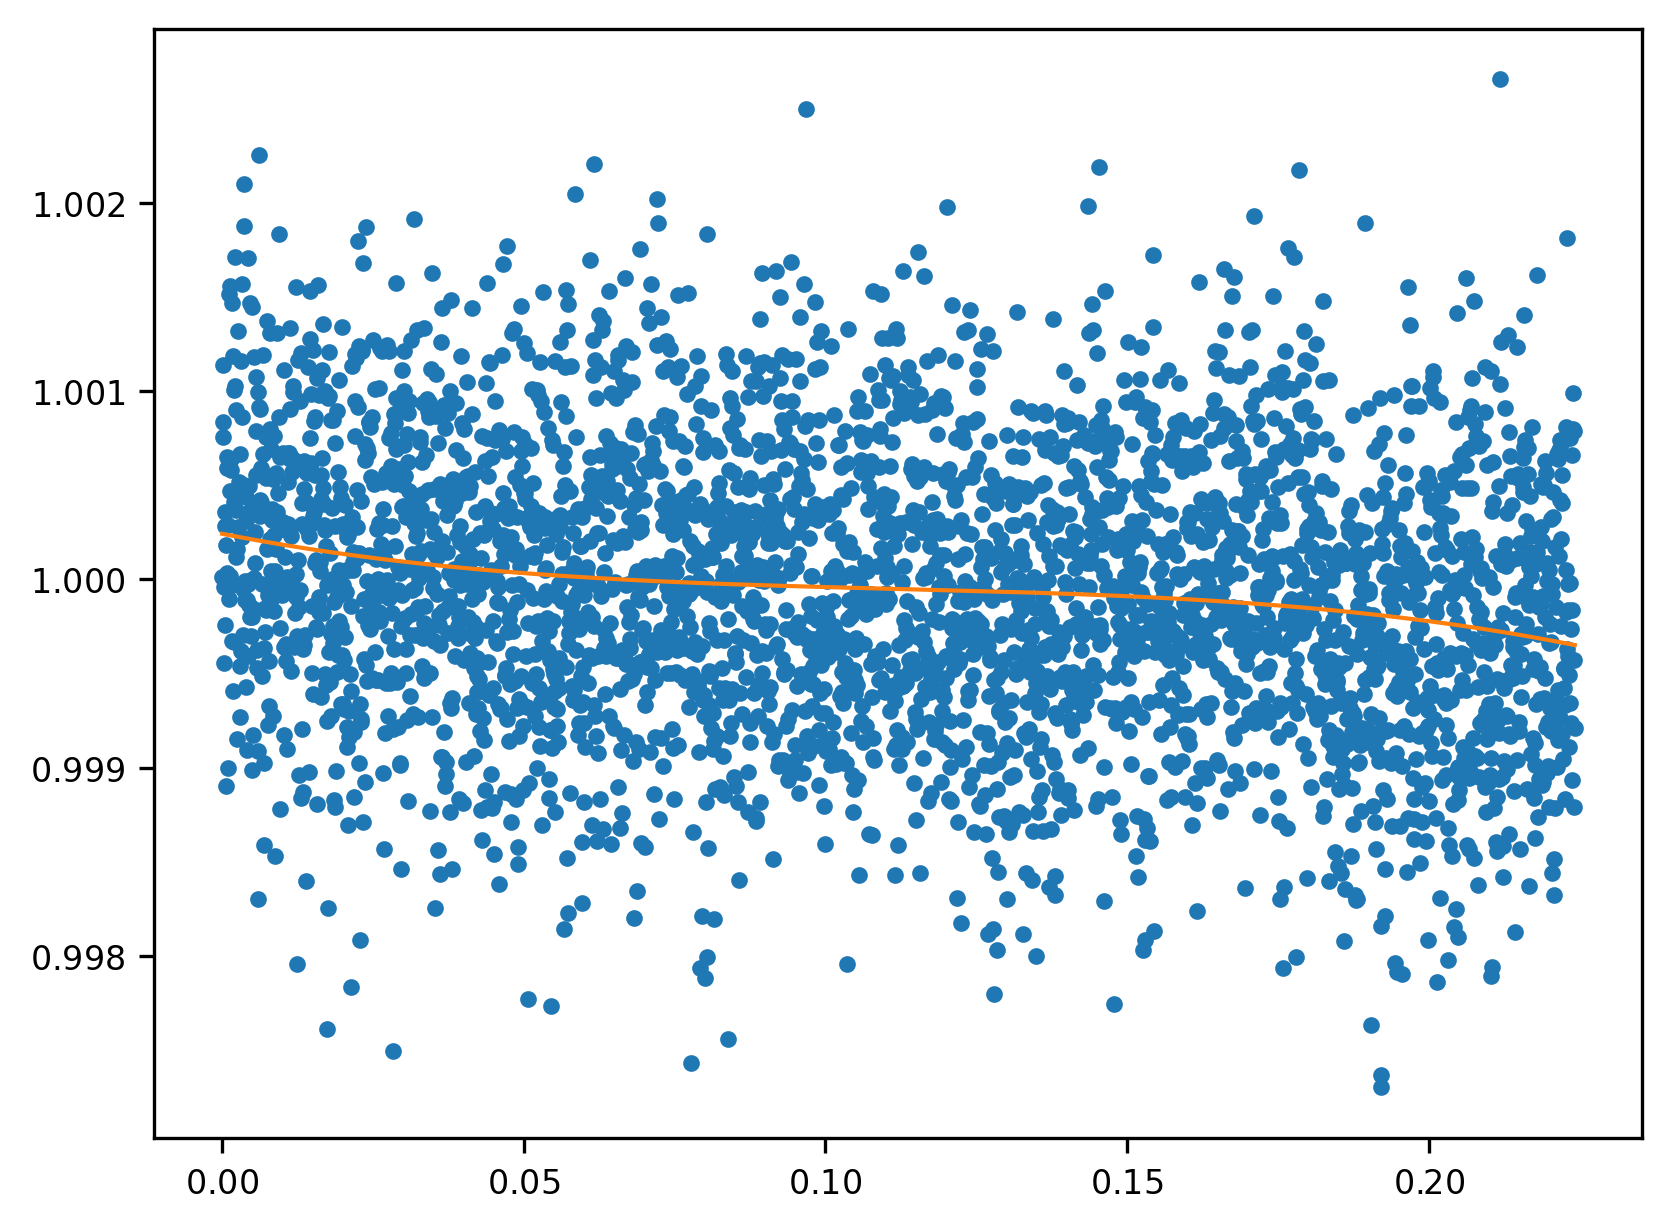

In [10]:
x = linear_visit_fits[2].time
x -= x.min()
y = linear_visit_fits[2].raw_flux
plt.plot(x, y, marker='.', linestyle='')

coeffs = np.polyfit(x, y, 3)
p = np.poly1d(coeffs)

y_fit = p(x)

plt.plot(x, y_fit)

print(coeffs)

In [11]:
fnpca_fps = np.array([f.results['fp'] for f in visit_fits])

max_diff = 0

for fp1 in fnpca_fps:
	for fp2 in fnpca_fps:
		s = np.sqrt(fp1.std_dev**2 + fp2.std_dev**2)
		diff = np.abs(fp1.nominal_value - fp2.nominal_value) / s
		if max_diff < diff:
			max_diff = diff
print(max_diff)

2.4770561935004998
